In [4]:
import pandas as pd
import matplotlib.pyplot as plt

print("Setup is working 🚀")

Setup is working 🚀


In [5]:
import pandas as pd

url = "https://raw.githubusercontent.com/guipsamora/pandas_exercises/master/07_Visualization/Online_Retail/Online_Retail.csv"

df = pd.read_csv(url, encoding='latin1')

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/10 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/10 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/10 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/10 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/10 8:26,3.39,17850.0,United Kingdom


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


# checking for missing values

In [8]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

# check where data is missing

In [9]:
df[df.isnull().any(axis=1)].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,12/1/10 11:52,0.00,NaN,United Kingdom
1443,536544,21773,DECORATIVE ROSE BATHROOM BOTTLE,1,12/1/10 14:32,2.51,NaN,United Kingdom
1444,536544,21774,DECORATIVE CATS BATHROOM BOTTLE,2,12/1/10 14:32,2.51,NaN,United Kingdom
1445,536544,21786,POLKADOT RAIN HAT,4,12/1/10 14:32,0.85,NaN,United Kingdom
1446,536544,21787,RAIN PONCHO RETROSPOT,2,12/1/10 14:32,1.66,NaN,United Kingdom


# Dataset Overview

The dataset contains **541,909 rows** and **8 columns**. It represents retail transaction data.

### 🔍 Column Details:
- **InvoiceNo**: Invoice number (object)
- **StockCode**: Product/item code (object)
- **Description**: Product description (some missing values)
- **Quantity**: Number of items purchased (integer)
- **InvoiceDate**: Date and time of transaction (needs conversion)
- **UnitPrice**: Price per item (float)
- **CustomerID**: Unique customer ID (many missing values)
- **Country**: Country of customer (object)

### ⚠️ Observations:
- Missing values present in:
  - Description (~1,454 missing)
  - CustomerID (~135,000 missing)
- InvoiceDate is currently in object format and needs conversion to datetime
- Dataset is large (~33 MB), suitable for real-world analysis

# Handling Missing Values

- CustomerID has a large number of missing values (~25%)
- Since customer-level analysis is not required for this project,
  this column will be ignored
- Description has a small number of missing values and will be handled during cleaning

In [13]:
df = df.dropna(subset=['Description'])

In [14]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description         0
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     133626
Country             0
dtype: int64

# Data Cleaning

- Removed rows with missing values in the **Description** column
- Ensured all product entries have valid names
- Observed that **CustomerID** still contains missing values (~133,000 rows)
- Since customer-level analysis is not required, this column will be ignored

### 📌 Result:
The dataset is now cleaner and ready for analysis

In [15]:
df['Revenue'] = df['Quantity'] * df['UnitPrice']

In [16]:
total_revenue = df['Revenue'].sum()
print("Total Revenue:", total_revenue)

Total Revenue: 9747747.933999997


In [17]:
top_products = df.groupby('Description')['Revenue'].sum().sort_values(ascending=False).head(10)

print(top_products)

Description
DOTCOM POSTAGE                        206245.48
REGENCY CAKESTAND 3 TIER              164762.19
WHITE HANGING HEART T-LIGHT HOLDER     99668.47
PARTY BUNTING                          98302.98
JUMBO BAG RED RETROSPOT                92356.03
RABBIT NIGHT LIGHT                     66756.59
POSTAGE                                66230.64
PAPER CHAIN KIT 50'S CHRISTMAS         63791.94
ASSORTED COLOUR BIRD ORNAMENT          58959.73
CHILLI LIGHTS                          53768.06
Name: Revenue, dtype: float64


# Revenue Analysis

#Total Revenue:
The total revenue generated from the dataset is approximately **9.74 million**.

#Top Performing Products:
The top 10 products contributing to revenue include:
- DOTCOM POSTAGE
- REGENCY CAKESTAND 3 TIER
- WHITE HANGING HEART T-LIGHT HOLDER
- PARTY BUNTING

#Key Insights:
- A small number of products contribute significantly to total revenue
- Shipping-related items like **POSTAGE** and **DOTCOM POSTAGE** generate high revenue
- Decorative and seasonal items are among the top-selling products

#Conclusion:
The dataset shows a strong concentration of revenue among a few high-performing products, indicating potential areas for business focus.

- The visualization clearly shows that a few products dominate revenue contribution

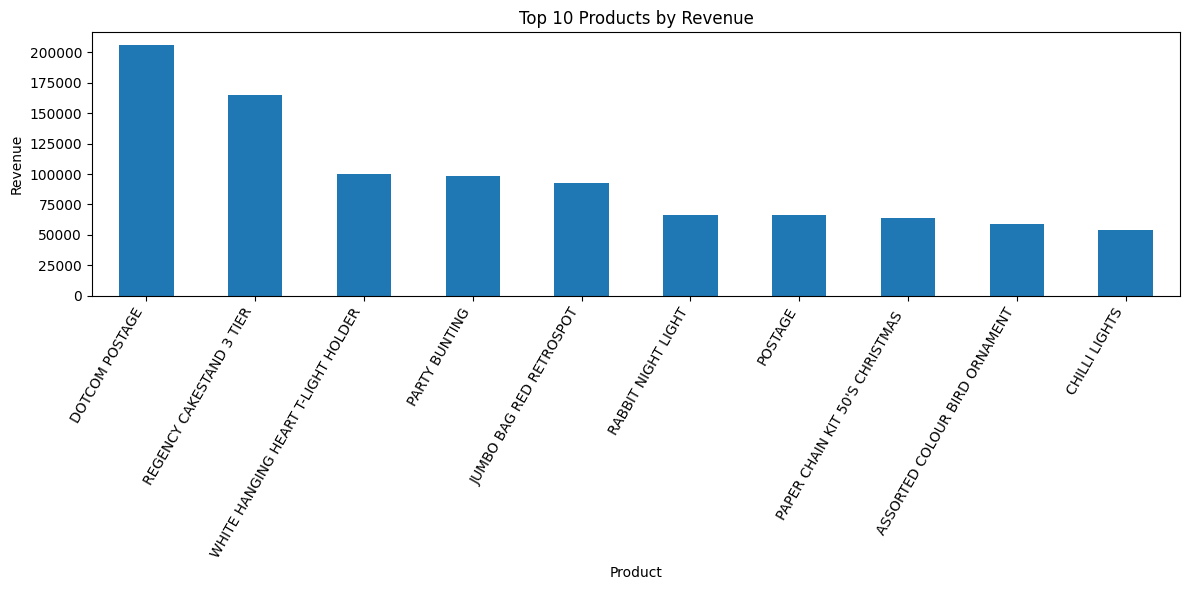

In [19]:
plt.figure(figsize=(12,6))

top_products.plot(kind='bar')

plt.title("Top 10 Products by Revenue")
plt.xlabel("Product")
plt.ylabel("Revenue")

plt.xticks(rotation=60, ha='right')  # better angle + alignment

plt.tight_layout()  # prevents cutting

plt.show()

# Monthly Sales Trend

In this section, we analyze how revenue changes over time by grouping sales data by month.

#Objective:
- Identify trends in sales over time
- Detect peak months and seasonal patterns

In [21]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], dayfirst=True)

In [22]:
monthly_sales = df.groupby('Month')['Revenue'].sum()

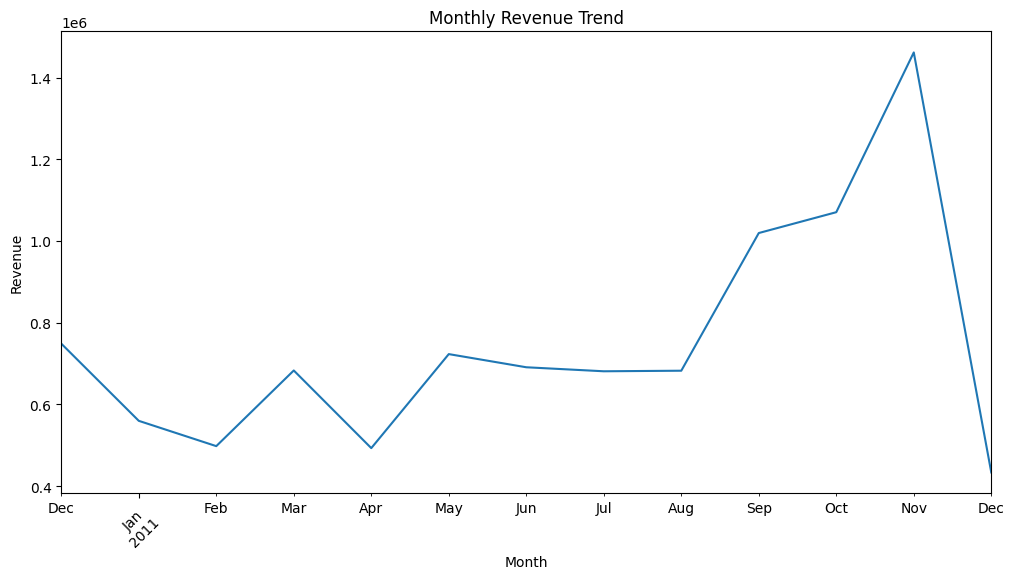

In [23]:
plt.figure(figsize=(12,6))

monthly_sales.plot()

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.show()

# Observations:
- The highest revenue is recorded in **November**
- There is a noticeable increase in sales towards the end of the year

#Insight:
- The peak in November is likely due to major shopping events like **Black Friday**
- Holiday season demand (Christmas and New Year) contributes to increased sales

#Conclusion:
The business experiences strong seasonal growth, especially during the festive period, which can be leveraged for marketing and inventory planning.

# Country-wise Sales Analysis

This section analyzes revenue distribution across different countries.

In [24]:
country_sales = df.groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(10)

print(country_sales)

Country
United Kingdom    8187806.364
Netherlands        284661.540
EIRE               263276.820
Germany            221698.210
France             197403.900
Australia          137077.270
Switzerland         56385.350
Spain               54774.580
Belgium             40910.960
Sweden              36595.910
Name: Revenue, dtype: float64


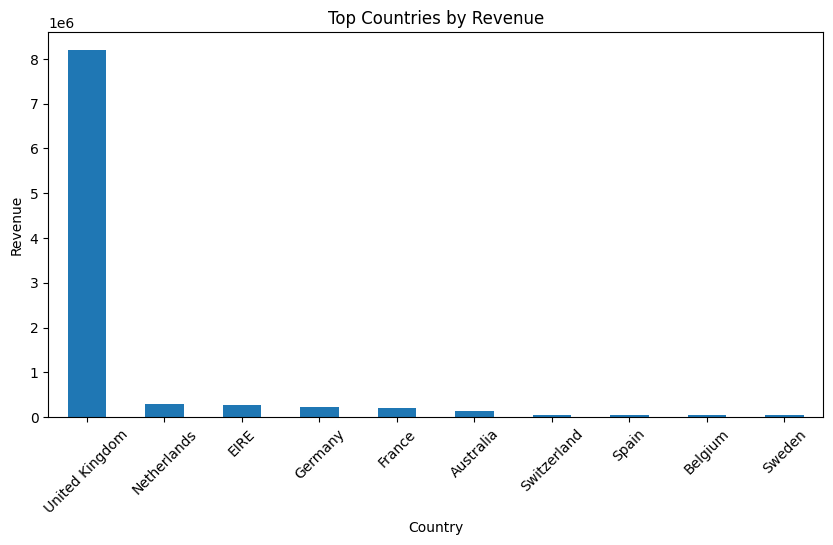

In [25]:
plt.figure(figsize=(10,5))

country_sales.plot(kind='bar')

plt.title("Top Countries by Revenue")
plt.xlabel("Country")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.show()

# Observations:
- The **United Kingdom (UK)** generates the highest revenue by a large margin
- Other countries contribute significantly less in comparison

#Insight:
- The business is heavily dependent on the UK market
- This indicates a strong customer base in the UK
- There is potential to expand in other countries to increase revenue

#Conclusion:
Geographical analysis shows that the UK is the primary revenue driver, suggesting opportunities for global expansion.

## Final Insights & Conclusion

### Key Findings:
- Total revenue generated is approximately **9.74 million**
- A small number of products contribute significantly to overall sales
- The highest sales occur in **November**, indicating strong seasonal demand
- The **UK** is the dominant market, generating the majority of revenue

### Overall Insight:
The business shows strong seasonal trends and is highly dependent on a specific geographical region (UK). Strategic focus on peak sales periods and market expansion could significantly improve performance.

### Future Improvements:
- Perform customer-level analysis (if data is available)
- Build predictive models for sales forecasting
- Create interactive dashboards using tools like Power BI or Streamlit